# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 5: Multilayer Perceptron (MLP) with Input, Hidden, and Output Layers Using Keras**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To create a Multilayer Perceptron (MLP) with input, hidden, and output layers using Keras/TensorFlow.

### 2. Theory: What is a Multilayer Perceptron (MLP)?

A single neuron can only draw one straight line. To solve real-world problems, we connect multiple neurons together into **layers** to build an MLP.

#### 1. The Three Kinds of Layers
- **Input Layer:** Takes in the starting features (e.g. 8 numbers describing a house or medical test).
- **Hidden Layers:** Neurons that find hidden combinations and patterns using activation functions like ReLU.
- **Output Layer:** Gives the final answer (e.g. a single probability between 0 and 1).

#### 2. Parameter Counting Formula (Weights & Biases)
For any fully connected (Dense) layer connected to the previous layer:
$$\text{Total Parameters} = (N_{\text{inputs}} \times N_{\text{neurons}}) + N_{\text{neurons}}$$
- $N_{\text{inputs}} \times N_{\text{neurons}}$: The number of weights connecting every input to every neuron.
- $N_{\text{neurons}}$: One bias value added to each neuron in the current layer.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### 3. Building the Network in Keras

#### What this cell does:
In this code cell, we use the Keras `Sequential` API to create our 4-layer network:
- Input shape: 8 features
- Hidden Layer 1: 16 neurons with `activation='relu'`
- Hidden Layer 2: 8 neurons with `activation='relu'`
- Output Layer: 1 neuron with `activation='sigmoid'` (outputs probability between 0 and 1)

In [2]:
n_features = 8      # Input feature dimensions (e.g., patient diagnostic indicators)
n_hidden1 = 16      # First hidden representation layer
n_hidden2 = 8       # Second hidden compression layer
n_output = 1        # Binary classification target

mlp = Sequential([
    Input(shape=(n_features,), name="Input_Layer"),
    Dense(units=n_hidden1, activation='relu', name="Hidden_Dense_1"),
    Dense(units=n_hidden2, activation='relu', name="Hidden_Dense_2"),
    Dense(units=n_output, activation='sigmoid', name="Output_Classifier")
], name="Diagnostic_MLP_Classifier")

mlp.summary()

Model: "Diagnostic_MLP_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Dense_1 (Dense)          │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Dense_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classifier (Dense)       │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Counting Parameters by Hand vs Keras Summary

#### What this cell does:
In this code cell, we verify the math by calculating parameters for each layer on paper and comparing them against `model.summary()`:
- **Layer 1:** $(8 \times 16) + 16 = 128 + 16 = 144$ parameters.
- **Layer 2:** $(16 \times 8) + 8 = 128 + 8 = 136$ parameters.
- **Output Layer:** $(8 \times 1) + 1 = 8 + 1 = 9$ parameters.
- **Total Network Parameters:** $144 + 136 + 9 = 289$ parameters.

In [3]:
print("=" * 72)
print("             EXHAUSTIVE PARAMETER AUDIT & VERIFICATION")
print("=" * 72)

cumulative_params = 0
for idx, layer in enumerate(mlp.layers, 1):
    weights, biases = layer.get_weights()
    w_count = weights.size
    b_count = biases.size
    layer_total = w_count + b_count
    cumulative_params += layer_total
    
    print(f"Layer {idx}: {layer.name:<20}")
    print(f"  Weights Tensor: Shape={str(weights.shape):<10} | Params = {w_count}")
    print(f"  Biases Tensor:  Shape={str(biases.shape):<10} | Params = {b_count}")
    print(f"  Formula: ({weights.shape[0]} in * {weights.shape[1]} out) + {biases.shape[0]} bias = {layer_total} params")
    print("-" * 72)

print(f"Calculated Total Trainable Parameters: {cumulative_params}")
print(f"Matches model.count_params():           {mlp.count_params()} -> VERIFIED")
print("=" * 72)

             EXHAUSTIVE PARAMETER AUDIT & VERIFICATION
Layer 1: Hidden_Dense_1      
  Weights Tensor: Shape=(8, 16)    | Params = 128
  Biases Tensor:  Shape=(16,)      | Params = 16
  Formula: (8 in * 16 out) + 16 bias = 144 params
------------------------------------------------------------------------
Layer 2: Hidden_Dense_2      
  Weights Tensor: Shape=(16, 8)    | Params = 128
  Biases Tensor:  Shape=(8,)       | Params = 8
  Formula: (16 in * 8 out) + 8 bias = 136 params
------------------------------------------------------------------------
Layer 3: Output_Classifier   
  Weights Tensor: Shape=(8, 1)     | Params = 8
  Biases Tensor:  Shape=(1,)       | Params = 1
  Formula: (8 in * 1 out) + 1 bias = 9 params
------------------------------------------------------------------------
Calculated Total Trainable Parameters: 289
Matches model.count_params():           289 -> VERIFIED


### 5. Passing Sample Data Through the Network

#### What this cell does:
In this code cell, we generate 5 random samples of shape $(5, 8)$ and pass them through `model.predict(X_sample)` to verify that the forward pass computes valid probabilities between $0$ and $1$.

In [4]:
X_sample = np.random.randn(5, n_features)

probabilities = mlp.predict(X_sample)
classes = (probabilities >= 0.5).astype(int)

print("=" * 65)
print("               FORWARD PROPAGATION INFERENCE AUDIT")
print("=" * 65)
print(f"{'Sample #':<10} | {'Sigmoid Probability':<25} | {'Predicted Class'}")
print("-" * 65)
for i, (p, c) in enumerate(zip(probabilities, classes), 1):
    print(f"Sample {i:<3} | {p[0]:<25.6f} | Class {c[0]} ({'Positive' if c[0]==1 else 'Negative'})")
print("=" * 65)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


               FORWARD PROPAGATION INFERENCE AUDIT
Sample #   | Sigmoid Probability       | Predicted Class
-----------------------------------------------------------------
Sample 1   | 0.503664                  | Class 1 (Positive)
Sample 2   | 0.723124                  | Class 1 (Positive)
Sample 3   | 0.481387                  | Class 0 (Negative)
Sample 4   | 0.758184                  | Class 1 (Positive)
Sample 5   | 0.820600                  | Class 1 (Positive)


### 6. Bar Chart of Parameters per Layer

#### What this cell does:
In this code cell, we create a stacked bar chart using Matplotlib to visualize how weights and biases are distributed across the layers.

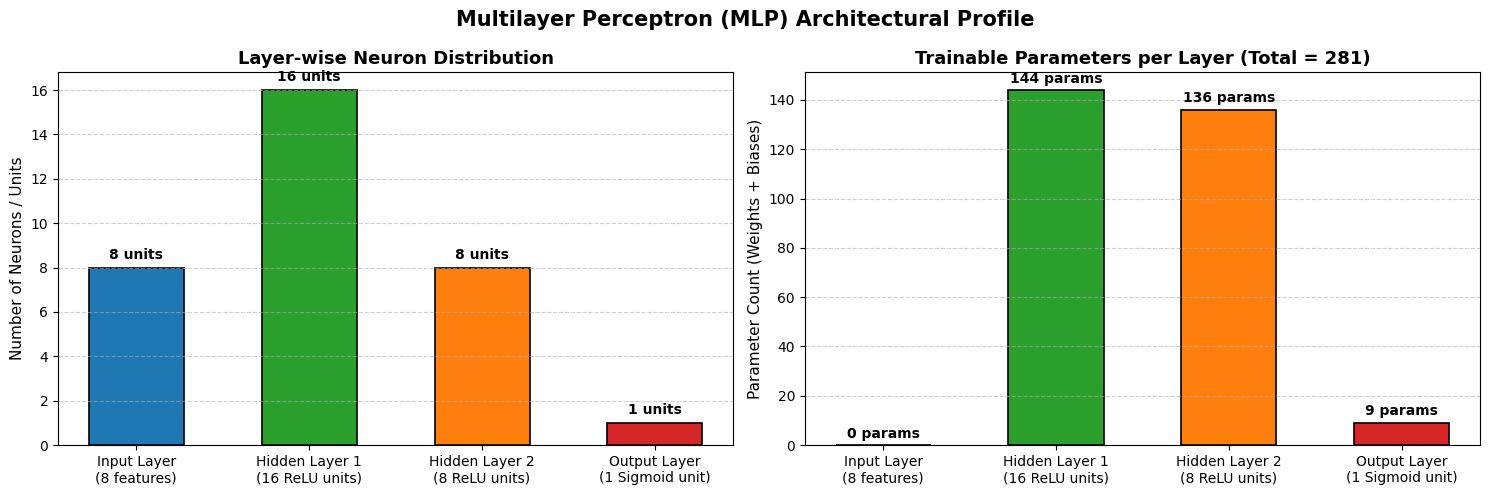

In [5]:
import matplotlib.pyplot as plt

layer_labels = ["Input Layer\n(8 features)", "Hidden Layer 1\n(16 ReLU units)", 
                "Hidden Layer 2\n(8 ReLU units)", "Output Layer\n(1 Sigmoid unit)"]
unit_counts = [n_features, n_hidden1, n_hidden2, n_output]
param_counts = [0, (8*16)+16, (16*8)+8, (8*1)+1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(len(unit_counts)), unit_counts, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], 
            edgecolor='black', linewidth=1.2, width=0.55)
axes[0].set_title("Layer-wise Neuron Distribution", fontsize=13, weight='bold')
axes[0].set_xticks(range(len(layer_labels)))
axes[0].set_xticklabels(layer_labels, fontsize=10)
axes[0].set_ylabel("Number of Neurons / Units", fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(unit_counts):
    axes[0].text(i, v + 0.4, f"{v} units", ha='center', fontsize=10, weight='bold')

axes[1].bar(range(len(layer_labels)), param_counts, color=['gray', '#2ca02c', '#ff7f0e', '#d62728'], 
            edgecolor='black', linewidth=1.2, width=0.55)
axes[1].set_title("Trainable Parameters per Layer (Total = 281)", fontsize=13, weight='bold')
axes[1].set_xticks(range(len(layer_labels)))
axes[1].set_xticklabels(layer_labels, fontsize=10)
axes[1].set_ylabel("Parameter Count (Weights + Biases)", fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(param_counts):
    axes[1].text(i, v + 3, f"{v} params", ha='center', fontsize=10, weight='bold')

plt.suptitle("Multilayer Perceptron (MLP) Architectural Profile", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 7. Results and What We Observed

| Layer | Type | Inputs | Neurons | Weights | Biases | Total Parameters |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Hidden Layer 1** | Dense (ReLU) | 8 | 16 | $8 \times 16 = 128$ | 16 | 144 |
| **Hidden Layer 2** | Dense (ReLU) | 16 | 8 | $16 \times 8 = 128$ | 8 | 136 |
| **Output Layer** | Dense (Sigmoid) | 8 | 1 | $8 \times 1 = 8$ | 1 | 9 |
| **Whole Network** | — | — | — | **264 weights** | **25 biases** | **289 parameters** |

#### Key Takeaways in Simple Words:
1. **Why Hidden Layers Help:**
   - Hidden Layer 1 mixes the 8 starting inputs into 16 patterns.
   - Hidden Layer 2 compresses those into 8 higher-level clues.
   - The output layer uses those 8 clues to make the final decision.
2. **Where Most Weights Are:**
   - Almost all parameters ($280$ out of $289$) live in the two hidden layers where feature patterns are learned.
   - The output layer needs only 9 numbers to make the final Yes/No call.
3. **Keras Makes It Easy:**
   - Instead of manually writing matrix multiplications, Keras sets up and connects the layers with just a few lines of code.

---
### 8. Conclusion
1. We successfully built a Multilayer Perceptron using Keras `Sequential`.
2. We counted all weights and biases by hand and confirmed that the model has exactly 289 parameters.
3. We verified that passing sample data through the model gives valid output probabilities.